# Mesh and Latent Space Visualization

This notebook demonstrates:
1. Loading a mesh from the dataloader
2. Visualizing the original mesh
3. Encoding the mesh into latent space using VAE
4. Visualizing the latent representation (as a mesh since same dimension)
5. Decoding the latent back to mesh
6. Visualizing the decoded/reconstructed mesh


In [1]:
import sys
sys.path.append('.')

# Set CUDA device before importing torch
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
import numpy as np
import yaml
import trimesh
from torch.utils.data import DataLoader
from functools import partial
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from datasets.mesh_dataset import ObjaverseDataset, collate_fn
from models.equivae import AutoencoderKL
from models.equivae import float_to_index_np, index_to_float_np

print("Imports successful!")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")


Imports successful!
CUDA_VISIBLE_DEVICES: 0


In [2]:
# Load VAE configuration
config_path = 'configs/vae.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Construct VAE checkpoint path from config (or use default)
# Checkpoint is typically at: output/{exp_name}/checkpoints/{step}.pt
# Using a common checkpoint path - you can modify this
exp_name = config['train']['exp_name']
output_dir = config['train']['output_dir']
# Try to find the latest checkpoint, or use a specific one
import os
from glob import glob
checkpoint_dir = f"{output_dir}/{exp_name}/checkpoints"
if os.path.exists(checkpoint_dir):
    checkpoint_files = glob(f"{checkpoint_dir}/*.pt")
    if checkpoint_files:
        checkpoint_files.sort(key=lambda x: int(os.path.basename(x).split('.')[0]))
        vae_ckpt_path = checkpoint_files[-1]  # Use latest checkpoint
    else:
        vae_ckpt_path = None
else:
    vae_ckpt_path = None

# Default scale factor (not in VAE config, but used in latent training)
latent_scale_factor = 0.1666

print("VAE Configuration loaded:")
print(f"  Data path: {config['data']['data_path']}")
print(f"  VAE checkpoint: {vae_ckpt_path if vae_ckpt_path else 'Not found - will use random init'}")
print(f"  Latent channels: {config['model']['latent_channels']}")
print(f"  Decoder type: {config['model']['decoder_type']}")
print(f"  Scale factor: {latent_scale_factor} (default)")


VAE Configuration loaded:
  Data path: downloaded_data/objaverse
  VAE checkpoint: output/vae_rms/checkpoints/0130000.pt
  Latent channels: 3
  Decoder type: reg
  Scale factor: 0.1666 (default)


In [3]:
# Helper function to convert tokens to vertices and faces for visualization
def simple_detokenize_mesh(tokens):
    """
    Convert tokens [N, 9] to vertices and faces.
    Each row represents 3 vertices of a triangle (3 vertices * 3 coords = 9 values).
    """
    coords = tokens.reshape(-1, 3).astype(np.float32)
    vertices = coords
    faces = np.arange(len(vertices)).reshape(-1, 3)
    # Convert from zyx to xyz
    vertices = vertices[:, [2, 1, 0]]
    return vertices, faces

def visualize_mesh_3d(vertices, faces, title="Mesh", ax=None):
    """
    Visualize a mesh using matplotlib 3D.
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
    
    # Create mesh using trimesh for cleaning
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    mesh.merge_vertices()
    mesh.update_faces(mesh.unique_faces())
    mesh.fix_normals()
    
    # Get cleaned vertices and faces
    vertices_clean = mesh.vertices
    faces_clean = mesh.faces
    
    # Plot the mesh
    ax.clear()
    
    # Create Poly3DCollection for faces
    triangles = vertices_clean[faces_clean]
    collection = Poly3DCollection(triangles, alpha=0.6, edgecolor='black', linewidths=0.5)
    collection.set_facecolor('lightblue')
    ax.add_collection3d(collection)
    
    # Set equal aspect ratio
    max_range = np.array([vertices_clean[:, 0].max() - vertices_clean[:, 0].min(),
                          vertices_clean[:, 1].max() - vertices_clean[:, 1].min(),
                          vertices_clean[:, 2].max() - vertices_clean[:, 2].min()]).max() / 2.0
    mid_x = (vertices_clean[:, 0].max() + vertices_clean[:, 0].min()) * 0.5
    mid_y = (vertices_clean[:, 1].max() + vertices_clean[:, 1].min()) * 0.5
    mid_z = (vertices_clean[:, 2].max() + vertices_clean[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    return ax

print("Helper functions defined!")


Helper functions defined!


In [4]:
# Load dataset and dataloader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

dataset = ObjaverseDataset(
    data_pth=config['data']['data_path'],
    training=False,  # Use test set for visualization
    noise_sort=config['data']['noise_sort'],
    use_decimated_dataset=False,
    do_dataset_normalize=False,
    use_rot_aug=False,  # Disable augmentation for consistent visualization
    use_scale_aug=False,
    use_repa=False,
    use_permut_aug=False,
    overfit=False
)

dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    collate_fn=partial(collate_fn, max_seq_length=800)
)

print(f"Dataset size: {len(dataset)}")
print("Dataloader created!")

loader = iter(dataloader)

Using device: cuda
[INFO] Single Dataset Mode: Loading downloaded_data/objaverse
--- Processing dataset: downloaded_data/objaverse ---
Loaded split test.npz, count: 400
[INFO] Loading meshes from downloaded_data/objaverse/objaverse_occ_v5_ids...


Loading objaverse: 100%|██████████| 32436/32436 [00:00<00:00, 214515.61it/s]

Loaded 400 valid samples from downloaded_data/objaverse
[INFO] Filtering data with max_face_length=800...


Total Combined Dataset Size: 324
Dataset size: 324
Dataloader created!


In [5]:
# Get a sample mesh from the dataloader
data = next(loader)
tokens = data['tokens'][0]  # [N, 9]
mask = data['masks'][0]     # [N]
num_faces = data['num_faces'][0].item()

# Extract only valid tokens (remove padding)
tokens_valid = tokens[mask].cpu().numpy()  # [M, 9] where M is actual number of faces

print(f"Sample mesh loaded:")
print(f"  Number of faces: {num_faces}")
print(f"  Token shape: {tokens_valid.shape}")
print(f"  Token range: [{tokens_valid.min():.4f}, {tokens_valid.max():.4f}]")


Sample mesh loaded:
  Number of faces: 694
  Token shape: (694, 9)
  Token range: [-0.5000, 0.5000]


Original mesh:
  Vertices shape: (2082, 3)
  Faces shape: (694, 3)


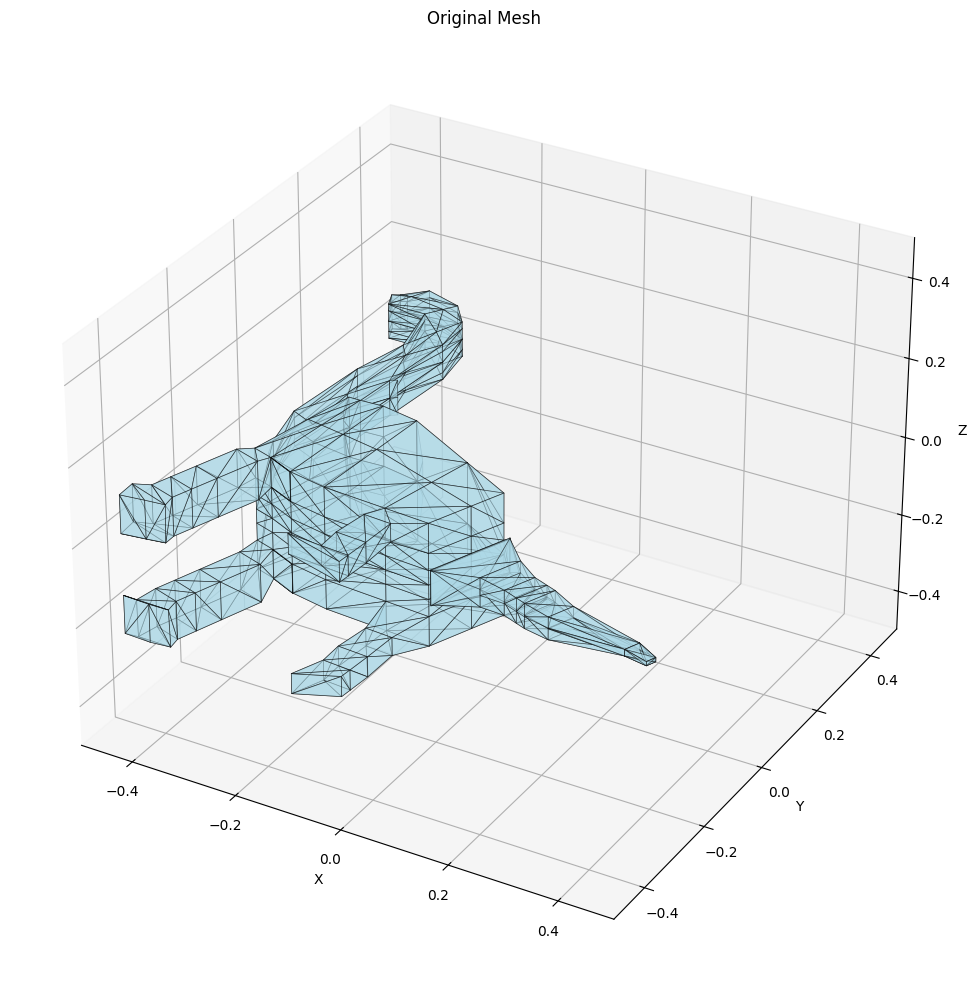

In [6]:
# Convert tokens to vertices and faces for visualization
vertices_orig, faces_orig = simple_detokenize_mesh(tokens_valid)

print(f"Original mesh:")
print(f"  Vertices shape: {vertices_orig.shape}")
print(f"  Faces shape: {faces_orig.shape}")

# Visualize original mesh
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
visualize_mesh_3d(vertices_orig, faces_orig, title="Original Mesh", ax=ax)
plt.tight_layout()
plt.show()


In [7]:
# Load VAE model
vae = AutoencoderKL(
    latent_channels=config['model']['latent_channels'],
    decoder_type=config['model']['decoder_type'],
    num_bins=config['data']['num_bins'],
    use_rmsnorm=config['model'].get('use_rms', False)  # VAE config uses 'use_rms' instead of 'use_rmsnorm'
).to(device)

# Load VAE checkpoint
if vae_ckpt_path and os.path.exists(vae_ckpt_path):
    vae_ckpt = torch.load(vae_ckpt_path, map_location='cpu')
    if 'ema' in vae_ckpt:
        vae.load_state_dict(vae_ckpt['ema'])
        print(f"Successfully loaded VAE from {vae_ckpt_path} (EMA weights)")
    elif 'model' in vae_ckpt:
        vae.load_state_dict(vae_ckpt['model'])
        print(f"Successfully loaded VAE from {vae_ckpt_path} (model weights)")
    else:
        vae.load_state_dict(vae_ckpt)
        print(f"Successfully loaded VAE from {vae_ckpt_path}")
else:
    print(f"Warning: VAE checkpoint not found at {vae_ckpt_path if vae_ckpt_path else 'None'}")
    print("Using randomly initialized VAE weights")

vae.eval()

print(f"VAE loaded and set to eval mode")
print(f"  Latent scale factor: {latent_scale_factor}")


Successfully loaded VAE from output/vae_rms/checkpoints/0130000.pt (EMA weights)
VAE loaded and set to eval mode
  Latent scale factor: 0.1666


In [18]:
# Encode mesh to latent space

# Note: noise_std is defined inside the torch.no_grad() block, so we need to access it
noise_std_value = 1.0 / 20.0  # 0.02
with torch.no_grad():
    # Prepare input: tokens [1, N, 9], num_faces [1], mask [1, N]
    # Ensure tokens and mask are tensors (they should be from dataloader)
    x_input = tokens.unsqueeze(0).to(device)  # [1, N, 9]
    # Convert num_faces (int) to tensor
    y_input = torch.tensor([num_faces], dtype=torch.long).to(device)  # [1]
    mask_input = mask.unsqueeze(0).to(device)  # [1, N]
    
    # Encode
    with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.bfloat16):
        posterior = vae.encode(x_input, cond=y_input, mask=mask_input)
        z = posterior.sample()  # [1, 3*N, latent_channels]
        
        # Get mean from posterior and add constant Gaussian noise
        z_mean = posterior.mean  # [1, 3*N, latent_channels]
    
    # Reshape latent to match mesh format [1, N, 9]
    # z is [1, 3*N, latent_channels], reshape to [1, N, 9]
    # View as [1, N, 3, latent_channels] then reshape to [1, N, 9]
    z_reshaped = z.view(z.shape[0], -1, 3, vae.latent_channels).reshape(z.shape[0], -1, 9)  # [1, N, 9]
    z_scaled = z_reshaped * latent_scale_factor  # Apply scale factor
    
    # Extract valid latents (for visualization)
    z_valid = z_scaled[0][mask].cpu().numpy()  # [M, 9]
    # Store the full z_scaled for decoding (keep on device)
    z_scaled_full = z_scaled

print(f"Latent encoding:")
print(f"  Original z shape: {z.shape}")
print(f"  Reshaped z_scaled shape: {z_scaled_full.shape}")
print(f"  Valid latent shape: {z_valid.shape}")
print(f"  Latent range: [{z_valid.min():.4f}, {z_valid.max():.4f}]")
print(f"  Latent mean: {z_valid.mean():.4f}, std: {z_valid.std():.4f}")
print(f"  Noise std used: {noise_std_value:.4f}")


Latent encoding:
  Original z shape: torch.Size([1, 2082, 3])
  Reshaped z_scaled shape: torch.Size([1, 694, 9])
  Valid latent shape: (694, 9)
  Latent range: [-2.9799, 2.7941]
  Latent mean: -0.4888, std: 1.1401
  Noise std used: 0.0500


Latent mesh:
  Vertices shape: (2082, 3)
  Faces shape: (694, 3)


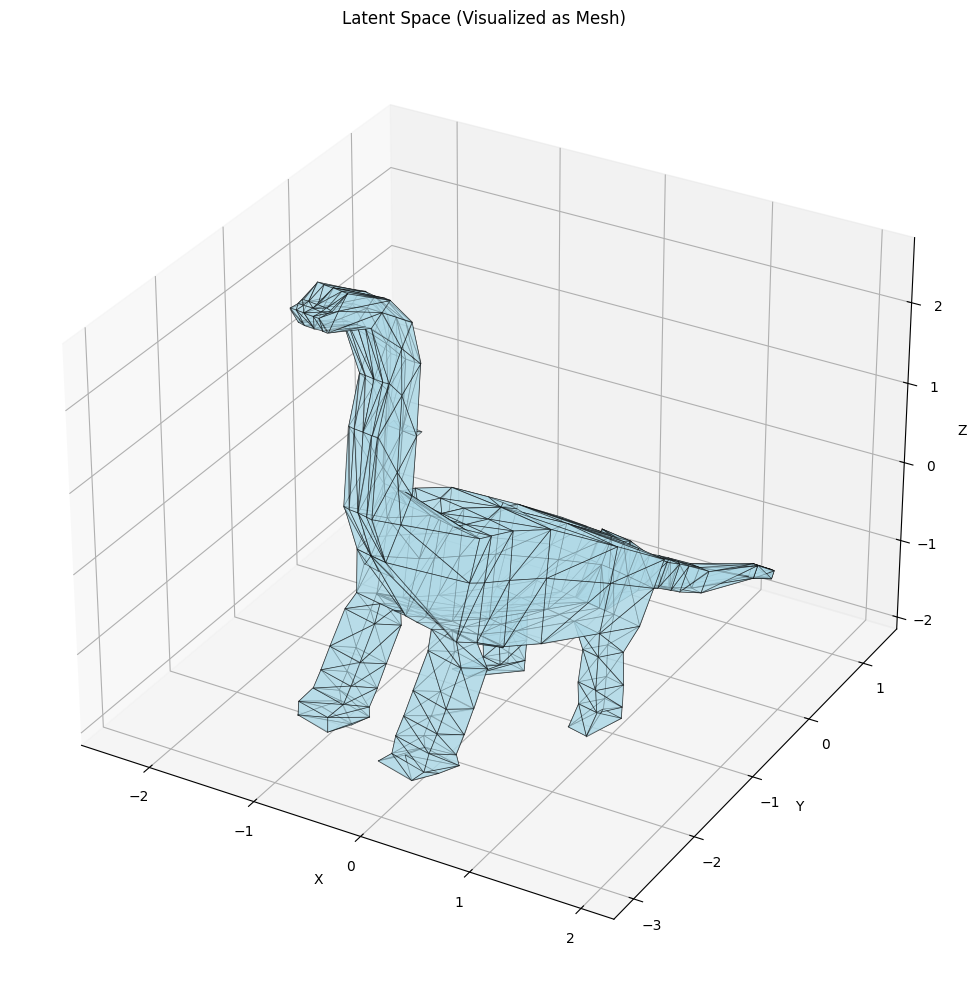

In [19]:
# Visualize latent as mesh (since same dimension)
# The latent has the same shape [N, 9] as the original mesh tokens
vertices_latent, faces_latent = simple_detokenize_mesh(z_valid)

print(f"Latent mesh:")
print(f"  Vertices shape: {vertices_latent.shape}")
print(f"  Faces shape: {faces_latent.shape}")

# Visualize latent as mesh
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
visualize_mesh_3d(vertices_latent, faces_latent, title="Latent Space (Visualized as Mesh)", ax=ax)
plt.tight_layout()
plt.show()


Mean + noise latent:
  Noise std used: 0.1000
  Mean+noise latent shape: (694, 9)
  Mean+noise range: [-3.0156, 2.8125]
Mean + noise latent mesh:
  Vertices shape: (2082, 3)
  Faces shape: (694, 3)


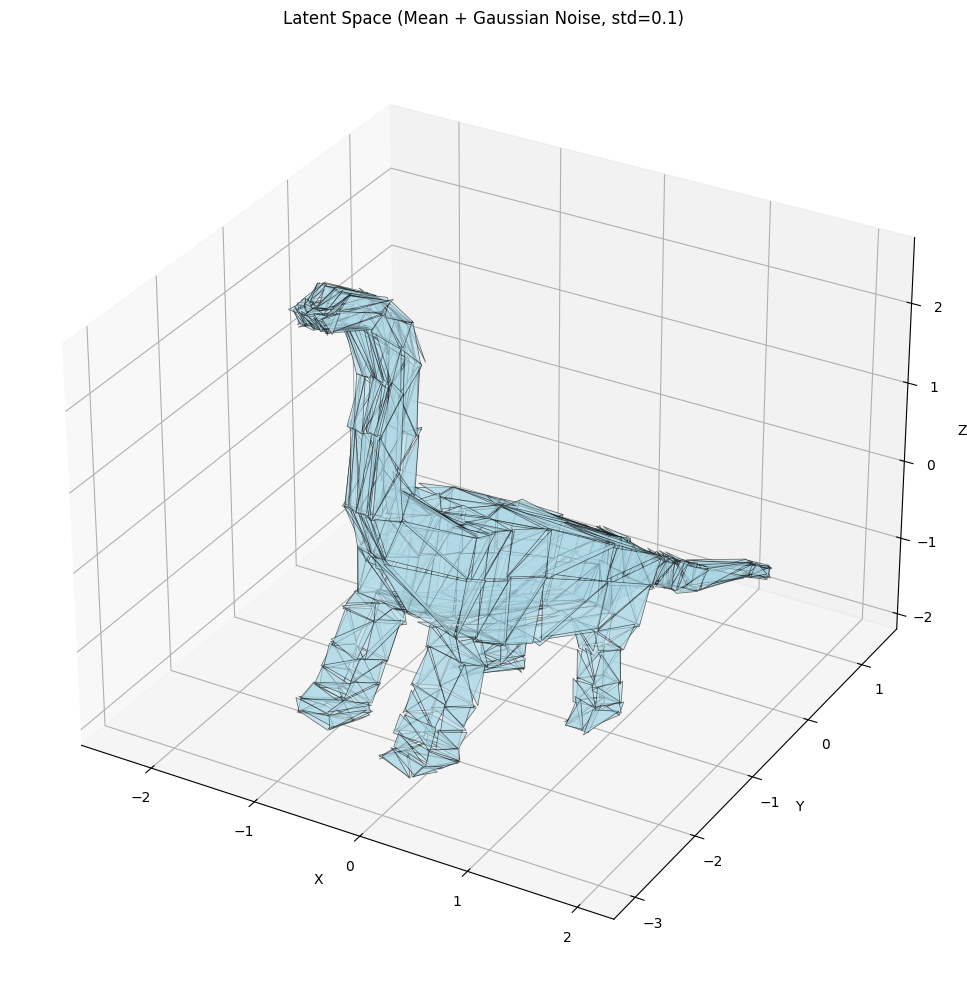

In [38]:
# Visualize latent with mean + constant Gaussian noise
# Add Gaussian noise with constant std = 1/50 = 0.02
noise_std_value = 5 / 50.0  # 0.02
with torch.no_grad():
    # Get mean from posterior and add constant Gaussian noise
    z_mean = posterior.mean  # [1, 3*N, latent_channels]
    gaussian_noise = torch.randn_like(z_mean) * noise_std_value
    z_mean_noisy = z_mean + gaussian_noise  # [1, 3*N, latent_channels]
    
    # Reshape mean with noise similarly
    z_mean_noisy_reshaped = z_mean_noisy.view(z_mean_noisy.shape[0], -1, 3, vae.latent_channels).reshape(z_mean_noisy.shape[0], -1, 9)  # [1, N, 9]
    z_mean_noisy_scaled = z_mean_noisy_reshaped * latent_scale_factor  # Apply scale factor
    
    # Store the full z_mean_noisy_scaled for decoding (keep on device)
    z_mean_noisy_scaled_full = z_mean_noisy_scaled
    
    # Extract valid latents (for visualization)
    z_mean_noisy_valid = z_mean_noisy_scaled[0].to(torch.float)[mask].cpu().numpy()  # [M, 9]

print(f"Mean + noise latent:")
print(f"  Noise std used: {noise_std_value:.4f}")
print(f"  Mean+noise latent shape: {z_mean_noisy_valid.shape}")
print(f"  Mean+noise range: [{z_mean_noisy_valid.min():.4f}, {z_mean_noisy_valid.max():.4f}]")

# The mean with noise has the same shape [N, 9] as the original mesh tokens
vertices_mean_noisy, faces_mean_noisy = simple_detokenize_mesh(z_mean_noisy_valid)

print(f"Mean + noise latent mesh:")
print(f"  Vertices shape: {vertices_mean_noisy.shape}")
print(f"  Faces shape: {faces_mean_noisy.shape}")

# Visualize mean + noise latent as mesh
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
visualize_mesh_3d(vertices_mean_noisy, faces_mean_noisy, title="Latent Space (Mean + Gaussian Noise, std=%s)" % noise_std_value, ax=ax)
plt.tight_layout()
plt.show()


In [39]:
# Decode mean + noise latent back to mesh
with torch.no_grad():
    # Prepare latent input: reshape from [1, N, 9] to [1, 3*N, latent_channels]
    # z_mean_noisy_scaled_full is [1, N, 9], we need [1, 3*N, latent_channels] for decode
    # Reshape: [1, N, 9] -> [1, 3*N, 3] = [1, 3*N, latent_channels] (when latent_channels=3)
    z_mean_noisy_input = z_mean_noisy_scaled_full / latent_scale_factor  # Remove scale factor for decoding
    z_mean_noisy_input_reshaped = z_mean_noisy_input.reshape(z_mean_noisy_input.shape[0], -1, vae.latent_channels)  # [1, 3*N, latent_channels]
    
    # Decode
    with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.bfloat16):
        recon_mean_noisy = vae.decode(z_mean_noisy_input_reshaped, cond=y_input, mask=mask_input)  # [1, N, 9]
    
    # Extract valid reconstructed tokens
    recon_mean_noisy_valid = recon_mean_noisy[0][mask].cpu().float().numpy()  # [M, 9]

print(f"Decoded mean + noise mesh:")
print(f"  Input to decode shape: {z_mean_noisy_input_reshaped.shape}")
print(f"  Reconstructed tokens shape: {recon_mean_noisy_valid.shape}")
print(f"  Reconstructed range: [{recon_mean_noisy_valid.min():.4f}, {recon_mean_noisy_valid.max():.4f}]")


Decoded mean + noise mesh:
  Input to decode shape: torch.Size([1, 2082, 3])
  Reconstructed tokens shape: (694, 9)
  Reconstructed range: [-0.5039, 0.5078]


Reconstructed mean + noise mesh:
  Vertices shape: (2082, 3)
  Faces shape: (694, 3)


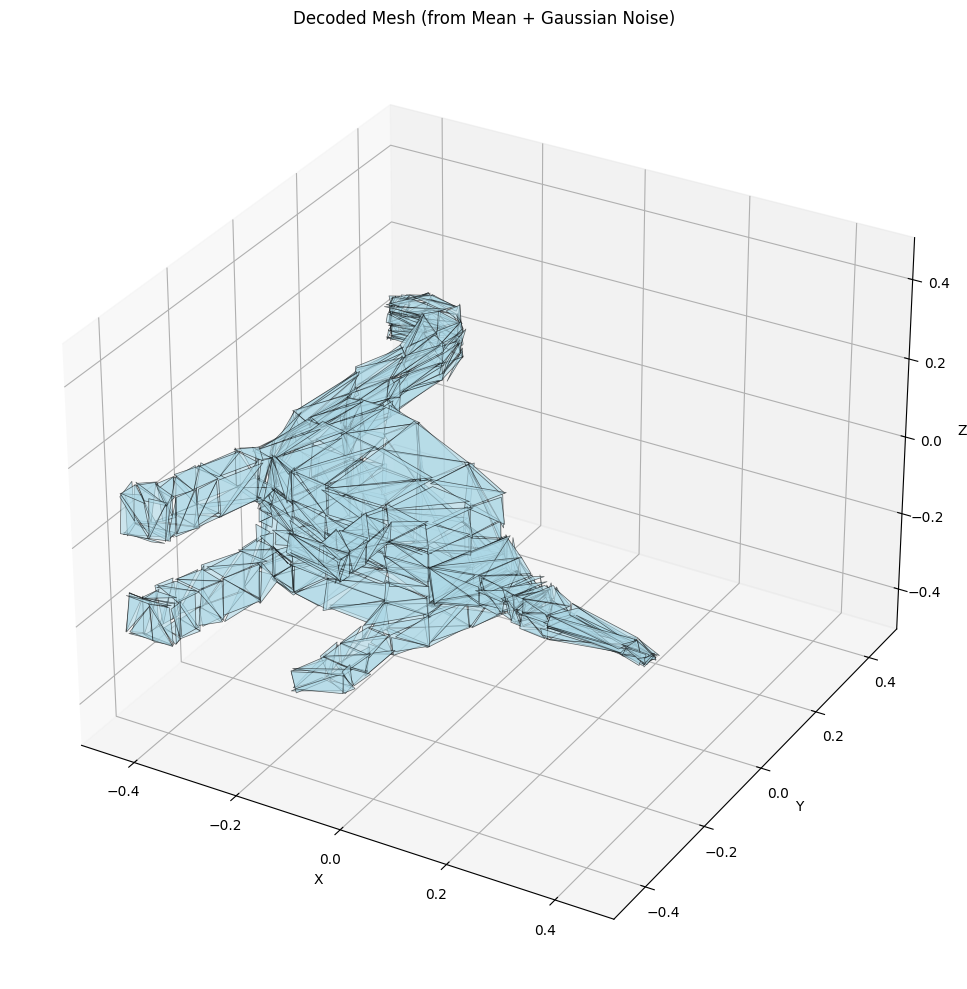

In [40]:
# Convert decoded mean + noise tokens to vertices and faces
vertices_recon_mean_noisy, faces_recon_mean_noisy = simple_detokenize_mesh(recon_mean_noisy_valid)

print(f"Reconstructed mean + noise mesh:")
print(f"  Vertices shape: {vertices_recon_mean_noisy.shape}")
print(f"  Faces shape: {faces_recon_mean_noisy.shape}")

# Visualize reconstructed mean + noise mesh
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
visualize_mesh_3d(vertices_recon_mean_noisy, faces_recon_mean_noisy, title="Decoded Mesh (from Mean + Gaussian Noise)", ax=ax)
plt.tight_layout()
plt.show()


In [23]:
# Decode latent back to mesh
with torch.no_grad():
    # Prepare latent input: reshape from [1, N, 9] to [1, 3*N, latent_channels]
    # z_scaled_full is [1, N, 9], we need [1, 3*N, latent_channels] for decode
    # Reshape: [1, N, 9] -> [1, 3*N, 3] = [1, 3*N, latent_channels] (when latent_channels=3)
    z_input = z_scaled_full / latent_scale_factor  # Remove scale factor for decoding
    z_input_reshaped = z_input.reshape(z_input.shape[0], -1, vae.latent_channels)  # [1, 3*N, latent_channels]
    
    # Decode
    with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.bfloat16):
        recon = vae.decode(z_input_reshaped, cond=y_input, mask=mask_input)  # [1, N, 9]
    
    # Extract valid reconstructed tokens
    recon_valid = recon[0][mask].cpu().float().numpy()  # [M, 9]

print(f"Decoded mesh:")
print(f"  Input to decode shape: {z_input_reshaped.shape}")
print(f"  Reconstructed tokens shape: {recon_valid.shape}")
print(f"  Reconstructed range: [{recon_valid.min():.4f}, {recon_valid.max():.4f}]")


Decoded mesh:
  Input to decode shape: torch.Size([1, 2082, 3])
  Reconstructed tokens shape: (694, 9)
  Reconstructed range: [-0.5000, 0.5000]


Reconstructed mesh:
  Vertices shape: (2082, 3)
  Faces shape: (694, 3)


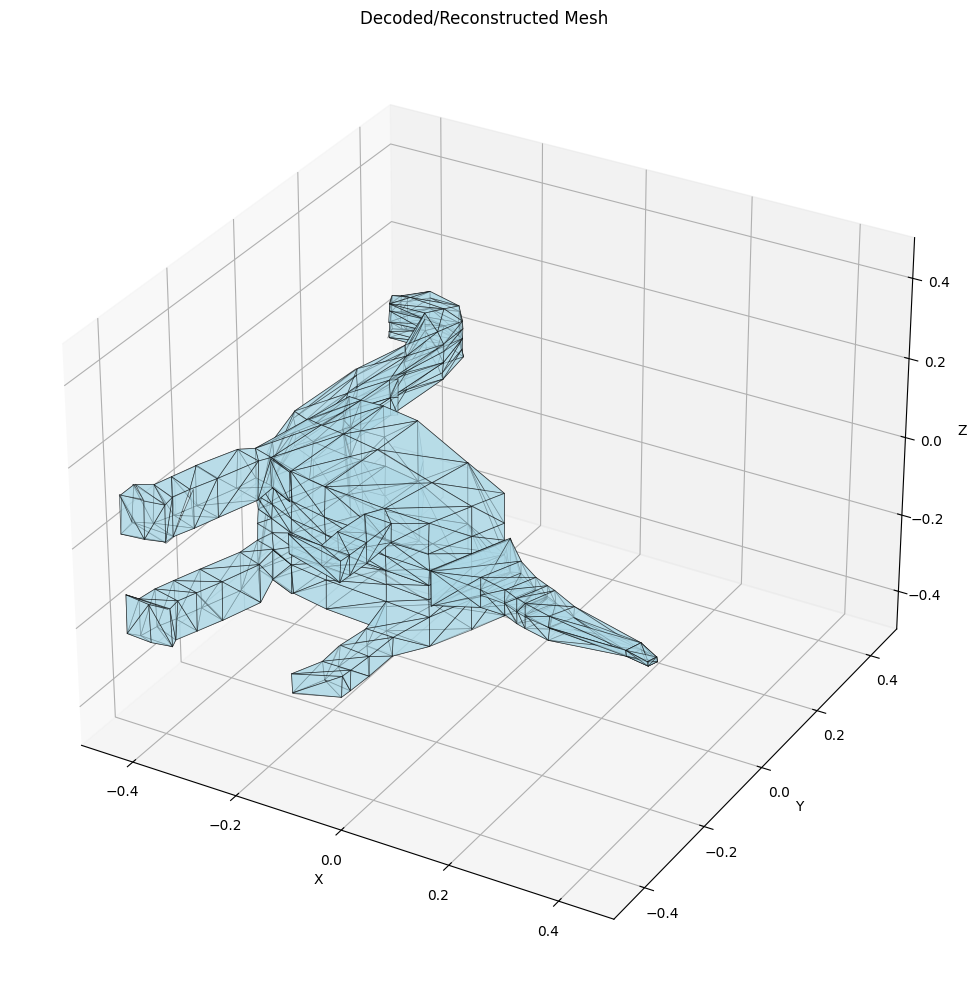

In [24]:
# Convert decoded tokens to vertices and faces
vertices_recon, faces_recon = simple_detokenize_mesh(recon_valid)

print(f"Reconstructed mesh:")
print(f"  Vertices shape: {vertices_recon.shape}")
print(f"  Faces shape: {faces_recon.shape}")

# Visualize reconstructed mesh
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
visualize_mesh_3d(vertices_recon, faces_recon, title="Decoded/Reconstructed Mesh", ax=ax)
plt.tight_layout()
plt.show()


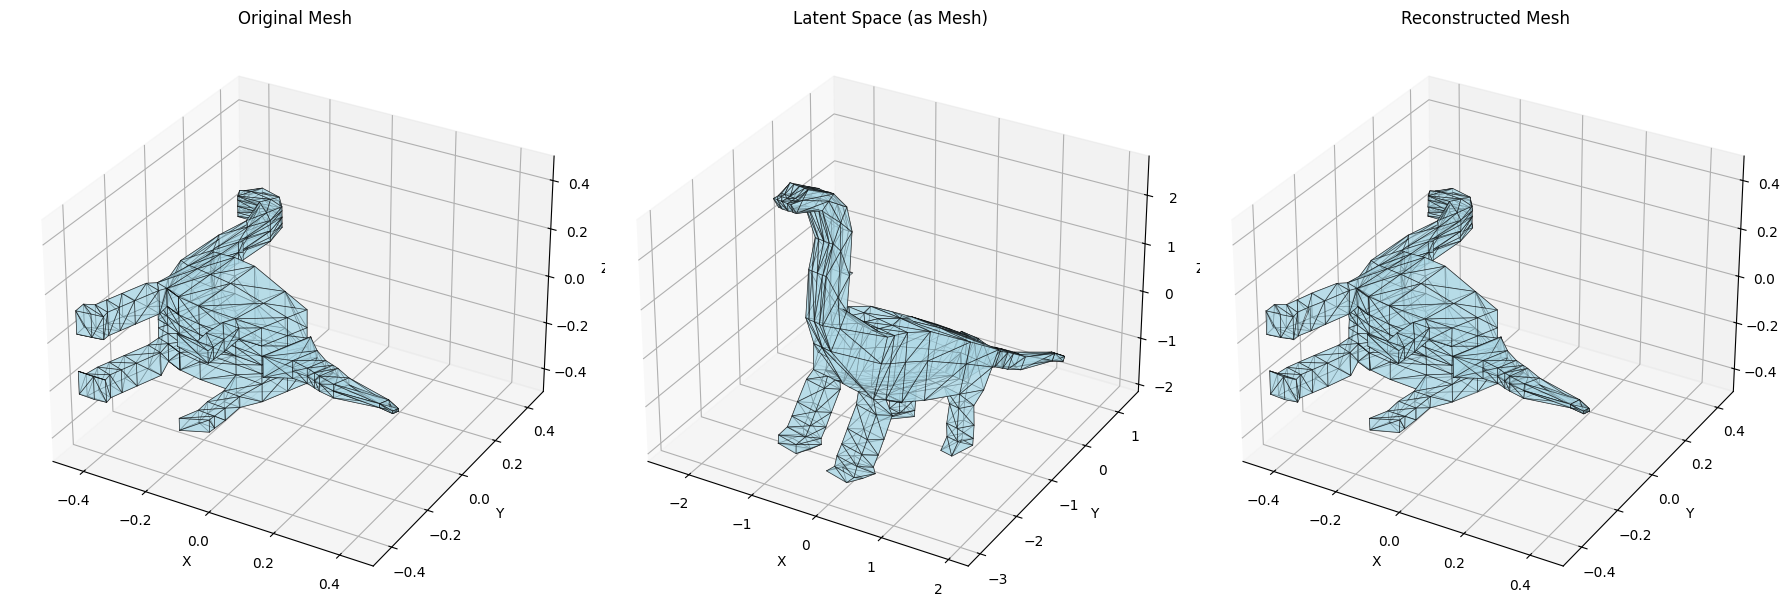

In [25]:
# Compare all three meshes side by side
fig = plt.figure(figsize=(18, 6))

# Original mesh
ax1 = fig.add_subplot(131, projection='3d')
visualize_mesh_3d(vertices_orig, faces_orig, title="Original Mesh", ax=ax1)

# Latent space (as mesh)
ax2 = fig.add_subplot(132, projection='3d')
visualize_mesh_3d(vertices_latent, faces_latent, title="Latent Space (as Mesh)", ax=ax2)

# Reconstructed mesh
ax3 = fig.add_subplot(133, projection='3d')
visualize_mesh_3d(vertices_recon, faces_recon, title="Reconstructed Mesh", ax=ax3)

plt.tight_layout()
plt.show()


In [26]:
# Calculate reconstruction error
mse = np.mean((tokens_valid - recon_valid) ** 2)
mae = np.mean(np.abs(tokens_valid - recon_valid))

print(f"Reconstruction Error:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  Relative Error: {mae / (np.abs(tokens_valid).mean() + 1e-8):.4%}")

# Compare statistics
print(f"\nStatistics Comparison:")
print(f"  Original tokens - mean: {tokens_valid.mean():.4f}, std: {tokens_valid.std():.4f}")
print(f"  Latent tokens   - mean: {z_valid.mean():.4f}, std: {z_valid.std():.4f}")
print(f"  Reconstructed   - mean: {recon_valid.mean():.4f}, std: {recon_valid.std():.4f}")


Reconstruction Error:
  MSE: 0.000001
  MAE: 0.000825
  Relative Error: 0.4023%

Statistics Comparison:
  Original tokens - mean: -0.0903, std: 0.2401
  Latent tokens   - mean: -0.4888, std: 1.1401
  Reconstructed   - mean: -0.0903, std: 0.2404
